In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

print("TensorFlow version :", tf.__version__)
print("Keras version :", keras.__version__)

SEED = 42
keras.utils.set_random_seed(SEED)  # seed python/numpy/tensorflow en un appel, pour la reproductibilité

I0000 00:00:1788385611.698130 2579334 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788385611.760746 2579334 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788385613.559473 2579334 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow version : 2.21.0
Keras version : 3.15.1


In [2]:
from pathlib import Path

In [3]:
# Configuration des chemins
# Les images vivent dans nutri-ia-data-collection (voir notebooks/README.md) —
# chemin identique pour les 3 notebooks de fine-tuning, pour comparer sur le même dataset.
DATA_DIR = Path("../../nutri-ia-data-collection/data/raw/images")
assert DATA_DIR.exists(), f"Dossier introuvable : {DATA_DIR.resolve()}"

# Extensions d'images valides
EXTENSIONS_VALIDES = {'.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'}

# Vérification des classes disponibles
classes = sorted([
    d for d in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, d))
])

print(f"Nombre de classes : {len(classes)}")
print(f"Classes détectées : {classes}")

# Comptage des images par classe
print("\nNombre d'images par classe :")
total = 0
for classe in classes:
    chemin = os.path.join(DATA_DIR, classe)
    nb_images = len([
        f for f in os.listdir(chemin)
        if os.path.splitext(f)[1] in EXTENSIONS_VALIDES
    ])
    total += nb_images
    print(f"  {classe} : {nb_images} images")

print(f"\nTotal : {total} images")

Nombre de classes : 6
Classes détectées : ['alloco', 'foutou', 'kedjenou', 'mafe', 'thieboudiene', 'yassa-poulet']

Nombre d'images par classe :
  alloco : 1100 images
  foutou : 1100 images
  kedjenou : 1101 images
  mafe : 1085 images
  thieboudiene : 1100 images
  yassa-poulet : 1100 images

Total : 6586 images


In [4]:
# Voir tout le contenu du dossier en détail
for item in os.listdir(DATA_DIR):
    chemin_complet = os.path.join(DATA_DIR, item)
    type_item = "DOSSIER" if os.path.isdir(chemin_complet) else "FICHIER"
    print(f"{type_item} → {item}")

DOSSIER → foutou
DOSSIER → thieboudiene
DOSSIER → kedjenou
DOSSIER → mafe
DOSSIER → yassa-poulet
DOSSIER → alloco
FICHIER → .gitkeep


In [5]:
# Chargement des données — split stratifié train/val/test (70/15/15)
# (au lieu du split 80/20 train/val de Keras : on garde un vrai jeu de test,
#  jamais vu par l'EarlyStopping/ReduceLROnPlateau, pour un score final non biaisé)
from sklearn.model_selection import train_test_split

IMG_SIZE   = (224, 224)  # Taille requise par EfficientNet-B0
BATCH_SIZE = 32          # Nombre d'images traitées à la fois

class_to_idx = {name: i for i, name in enumerate(classes)}
class_names  = classes
NUM_CLASSES  = len(class_names)

filepaths, file_labels = [], []
for classe in class_names:
    classe_dir = os.path.join(DATA_DIR, classe)
    for fname in os.listdir(classe_dir):
        if os.path.splitext(fname)[1] in EXTENSIONS_VALIDES:
            filepaths.append(os.path.join(classe_dir, fname))
            file_labels.append(class_to_idx[classe])

filepaths   = np.array(filepaths)
file_labels = np.array(file_labels)

# 70 % train / 15 % val / 15 % test, split stratifié par classe
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    filepaths, file_labels, test_size=0.30, stratify=file_labels, random_state=SEED
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.50, stratify=temp_labels, random_state=SEED
)

def _load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, IMG_SIZE)
    return img, label

def make_dataset(paths, labs, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labs))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)
    ds = ds.map(_load_image, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train_paths, train_labels, shuffle=True)
val_ds   = make_dataset(val_paths, val_labels)
test_ds  = make_dataset(test_paths, test_labels)

print(f"Classes : {class_names}")
print(f"Images d'entraînement : {len(train_paths)}")
print(f"Images de validation  : {len(val_paths)}")
print(f"Images de test        : {len(test_paths)}")
print("\nRépartition par classe (train / val / test) :")
for classe in class_names:
    idx  = class_to_idx[classe]
    n_tr = int((train_labels == idx).sum())
    n_va = int((val_labels == idx).sum())
    n_te = int((test_labels == idx).sum())
    print(f"  {classe:15s} {n_tr:3d} / {n_va:3d} / {n_te:3d}")

Classes : ['alloco', 'foutou', 'kedjenou', 'mafe', 'thieboudiene', 'yassa-poulet']
Images d'entraînement : 4610
Images de validation  : 988
Images de test        : 988

Répartition par classe (train / val / test) :
  alloco          770 / 165 / 165
  foutou          770 / 165 / 165
  kedjenou        771 / 165 / 165
  mafe            759 / 163 / 163
  thieboudiene    770 / 165 / 165
  yassa-poulet    770 / 165 / 165


E0000 00:00:1788385623.434381 2579334 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [6]:
# Construire le modèle EfficientNet-B0 

from tensorflow.keras import layers,models#un module de Keras qui contient toutes les briques de couches

# Augmentation de données (pour l'entraînement) ---
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="data_augmentation")

In [7]:
# Chargement du backbone EfficientNet-B0 pré-entraîné sur ImageNet

base_model = keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SIZE + (3,),
    pooling="avg" 
)    

base_model.trainable = False # Geler le backbone dans un premier temps 


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [8]:
# Assemblage du modèle complet 

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)

# normalisation interne (rescaling + normalisation ImageNet) s'en charge

x = keras.applications.efficientnet.preprocess_input(x)
 
x = base_model(x, training=False)  # training=False -> BatchNorm en mode inférence

In [9]:
# Tête de classification ---

x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
model = keras.Model(inputs, outputs, name="efficientnet_b0_classifier")
 
model.summary()

Model: "efficientnet_b0_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,049 (16.70 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [10]:
# Compilation — Phase 1 (backbone gelé) ---

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",  # labels entiers (pas one-hot)
    metrics=["accuracy"]
)
 
# Nombre de paramètres entraînables (tête uniquement, backbone gelé)
trainable_params = sum(
    tf.size(w).numpy() for w in model.trainable_weights
)
print(f"\nParamètres entraînables : {trainable_params:,}")


Paramètres entraînables : 329,478


In [11]:
# Entraînement Phase 1 (backbone gelé)

# Callbacks pour optimiser l'entraînement
callbacks_phase1 = [
    # S'arrête si la validation ne s'améliore plus après 5 epochs
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    # Réduit le learning rate si stagnation
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=1
    )
]

# Lancement de l'entraînement
history_phase1 = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=callbacks_phase1,
    verbose=1
)

print("\nEntraînement Phase 1 terminé !")

Epoch 1/20


/home/kabel/Documents/data_afrique_hub/departement_projets/projets/nutri-ia-model-training/.venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


145/145 ━━━━━━━━━━━━━━━━━━━━ 181s 1s/step - accuracy: 0.7824 - loss: 0.6046 - val_accuracy: 0.9089 - val_loss: 0.2922 - learning_rate: 0.0010
Epoch 2/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.8967 - loss: 0.2955 - val_accuracy: 0.9241 - val_loss: 0.2316 - learning_rate: 0.0010
Epoch 3/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 168s 1s/step - accuracy: 0.9241 - loss: 0.2227 - val_accuracy: 0.9534 - val_loss: 0.1495 - learning_rate: 0.0010
Epoch 4/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.9347 - loss: 0.1864 - val_accuracy: 0.9605 - val_loss: 0.1337 - learning_rate: 0.0010
Epoch 5/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.9388 - loss: 0.1795 - val_accuracy: 0.9585 - val_loss: 0.1269 - learning_rate: 0.0010
Epoch 6/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 168s 1s/step - accuracy: 0.9466 - loss: 0.1550 - val_accuracy: 0.9656 - val_loss: 0.1038 - learning_rate: 0.0010
Epoch 7/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 173s 1s/step - accuracy: 0.9588 - loss: 0.1281 - val_

In [ ]:
# Sauvegarde du modèle Phase 1 (baseline, backbone gelé) — export direct en .pt PyTorch
from keras_to_pt import export_keras_as_pt

os.makedirs("models", exist_ok=True)
test_batch = next(iter(test_ds))[0].numpy()
export_keras_as_pt(
    model,
    "models/efficientnet_b0_phase1.pt",
    backbone_layer_name="efficientnetb0",
    head_layer_names=["dropout", "dense", "dropout_1", "dense_1"],
    preprocess_fn=keras.applications.efficientnet.preprocess_input,
    test_input=test_batch,
)
print("Modèle Phase 1 sauvegardé dans models/efficientnet_b0_phase1.pt ✅")
print(f"Meilleure val_accuracy (Phase 1) : {max(history_phase1.history['val_accuracy']):.2%}")

In [13]:
# PHASE 2 : fine-tuning réel — dégel des dernières couches du backbone
# (jusqu'ici on n'avait fait que de l'extraction de features : backbone
#  toujours gelé, seule la tête était entraînée)

FINE_TUNE_AT = 20  # nombre de couches finales du backbone à dégeler (ajustable)

base_model.trainable = True
for layer in base_model.layers[:-FINE_TUNE_AT]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # LR très faible pour ne pas détruire les poids ImageNet
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

trainable_params = sum(tf.size(w).numpy() for w in model.trainable_weights)
print(f"Phase 2 — paramètres entraînables (backbone partiellement dégelé) : {trainable_params:,}")

callbacks_phase2 = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
]

print("\n=== Phase 2 : fine-tuning du backbone ===")
history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks_phase2,
    verbose=1,
)
print("\nFine-tuning terminé !")

Phase 2 — paramètres entraînables (backbone partiellement dégelé) : 1,459,254

=== Phase 2 : fine-tuning du backbone ===
Epoch 1/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 180s 1s/step - accuracy: 0.8137 - loss: 0.5933 - val_accuracy: 0.9524 - val_loss: 0.1224 - learning_rate: 1.0000e-05
Epoch 2/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 168s 1s/step - accuracy: 0.8512 - loss: 0.4351 - val_accuracy: 0.9433 - val_loss: 0.1658 - learning_rate: 1.0000e-05
Epoch 3/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 168s 1s/step - accuracy: 0.8761 - loss: 0.3563 - val_accuracy: 0.9453 - val_loss: 0.1580 - learning_rate: 1.0000e-05
Epoch 4/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9004 - loss: 0.3094
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
145/145 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.9004 - loss: 0.3094 - val_accuracy: 0.9453 - val_loss: 0.1439 - learning_rate: 1.0000e-05
Epoch 5/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 194s 1s/step - accuracy: 0.8983 - loss: 0.3096 - val_accuracy

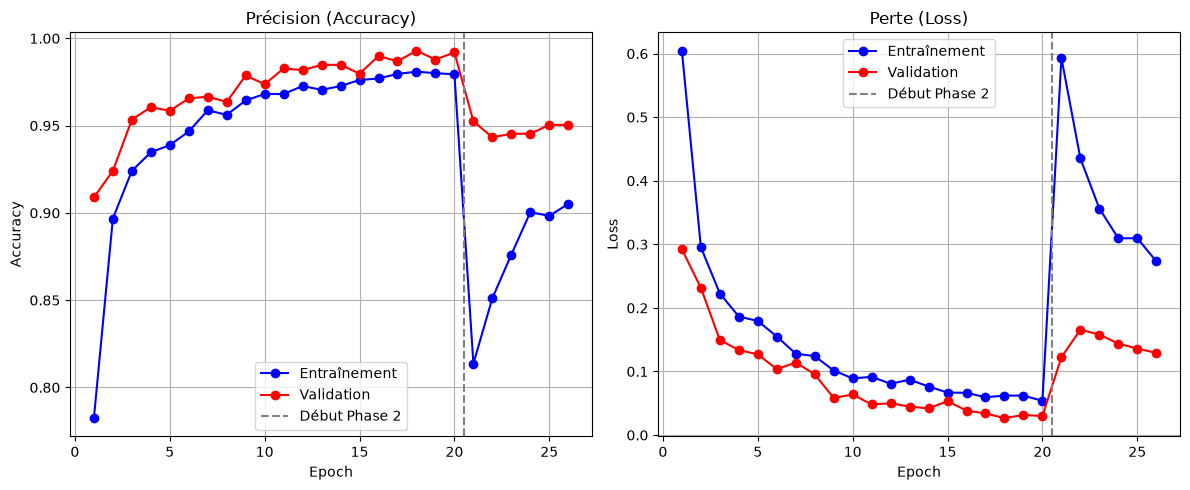

Courbes sauvegardées !


In [14]:
# Visualisation des courbes d'entraînement (Phase 1 + Phase 2 concaténées)

import matplotlib.pyplot as plt

acc      = history_phase1.history["accuracy"]     + history_finetune.history["accuracy"]
val_acc  = history_phase1.history["val_accuracy"]  + history_finetune.history["val_accuracy"]
loss     = history_phase1.history["loss"]          + history_finetune.history["loss"]
val_loss = history_phase1.history["val_loss"]      + history_finetune.history["val_loss"]
epochs = range(1, len(acc) + 1)
phase2_start = len(history_phase1.history["accuracy"]) + 0.5  # position de la transition Phase1→Phase2

plt.figure(figsize=(12, 5))

# Courbe Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, acc,  "b-o", label="Entraînement")
plt.plot(epochs, val_acc, "r-o", label="Validation")
plt.axvline(phase2_start, color="gray", linestyle="--", label="Début Phase 2")
plt.title("Précision (Accuracy)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Courbe Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss,     "b-o", label="Entraînement")
plt.plot(epochs, val_loss, "r-o", label="Validation")
plt.axvline(phase2_start, color="gray", linestyle="--", label="Début Phase 2")
plt.title("Perte (Loss)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("courbes_entrainement.png", dpi=150)
plt.show()
print("Courbes sauvegardées !")

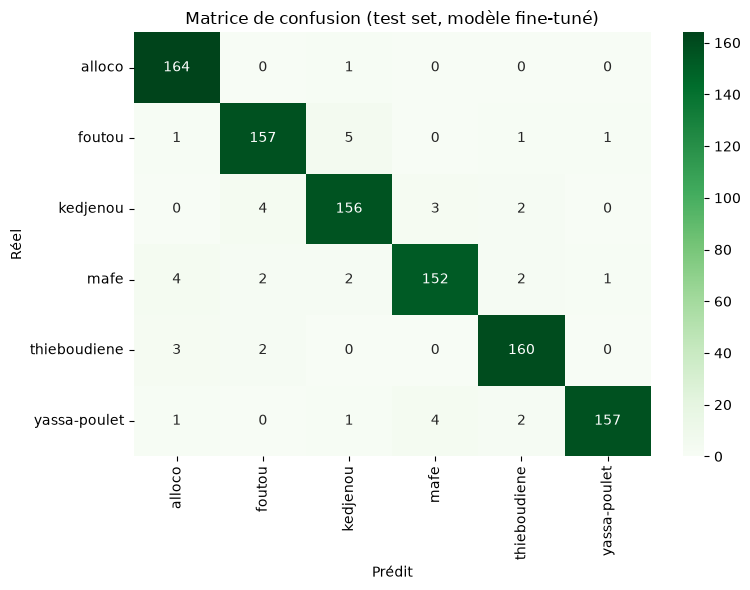


Rapport détaillé (test set) :
              precision    recall  f1-score   support

      alloco       0.95      0.99      0.97       165
      foutou       0.95      0.95      0.95       165
    kedjenou       0.95      0.95      0.95       165
        mafe       0.96      0.93      0.94       163
thieboudiene       0.96      0.97      0.96       165
yassa-poulet       0.99      0.95      0.97       165

    accuracy                           0.96       988
   macro avg       0.96      0.96      0.96       988
weighted avg       0.96      0.96      0.96       988



In [15]:
# Matrice de confusion — évaluée sur le jeu de TEST (jamais vu par les callbacks)
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Prédictions sur le test set
y_pred = []
y_true = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Greens")
plt.title("Matrice de confusion (test set, modèle fine-tuné)")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.tight_layout()
plt.savefig("matrice_confusion.png", dpi=150)
plt.show()

print("\nRapport détaillé (test set) :")
report_text = classification_report(y_true, y_pred, target_names=class_names)
print(report_text)

In [ ]:
# Sauvegarde du modèle fine-tuné (Phase 2) + métadonnées — export direct en .pt PyTorch
import json
from pathlib import Path as _Path
from keras_to_pt import export_keras_as_pt

os.makedirs("models", exist_ok=True)
test_batch = next(iter(test_ds))[0].numpy()
export_keras_as_pt(
    model,
    "models/efficientnet_b0_finetuned.pt",
    backbone_layer_name="efficientnetb0",
    head_layer_names=["dropout", "dense", "dropout_1", "dense_1"],
    preprocess_fn=keras.applications.efficientnet.preprocess_input,
    test_input=test_batch,
)

# class_names sauvegardé à côté du modèle : sans ça, impossible de savoir plus tard
# quel index de sortie correspond à quel plat.
with open("models/efficientnet_b0_classes.json", "w") as f:
    json.dump(class_names, f, ensure_ascii=False, indent=2)

# Rapport texte exporté (au même format que reports/*.txt utilisé pour le modèle d'embedding)
reports_dir = _Path("../reports")
reports_dir.mkdir(parents=True, exist_ok=True)
with open(reports_dir / "keras_efficientnet_report.txt", "w") as f:
    f.write("RAPPORT — EfficientNetB0 (entraîné avec Keras, exporté en PyTorch .pt), Phase 1 + Phase 2\n")
    f.write("=" * 60 + "\n\n")
    f.write(f"Images train/val/test : {len(train_paths)}/{len(val_paths)}/{len(test_paths)}\n")
    f.write(f"Classes : {class_names}\n\n")
    f.write(f"Meilleure val_accuracy Phase 1 : {max(history_phase1.history['val_accuracy']):.2%}\n")
    f.write(f"Meilleure val_accuracy Phase 2 : {max(history_finetune.history['val_accuracy']):.2%}\n\n")
    f.write("Rapport de classification (test set) :\n")
    f.write(report_text)

print("Modèle fine-tuné sauvegardé dans models/efficientnet_b0_finetuned.pt ✅")
print("Classes sauvegardées dans models/efficientnet_b0_classes.json ✅")
print("Rapport sauvegardé dans reports/keras_efficientnet_report.txt ✅")
print(f"Meilleure val_accuracy (Phase 2) : {max(history_finetune.history['val_accuracy']):.2%}")

In [ ]:
# Test rapide sur une image isolée — utilise le modèle Keras encore en mémoire (post-entraînement)
#
# NB : ne PAS faire torch.load(...) ici en plus de tensorflow dans le même kernel — un
# plantage natif (segfault) a été observé en mélangeant torch.load et un kernel TF déjà
# chargé. Le fichier .pt exporté est prévu pour être chargé dans un script/environnement
# PyTorch séparé (voir notebooks/README.md), pas dans ce notebook.
#
# NB2 : pas de preprocess_input ici — le modèle Keras l'applique déjà en interne
# (voir la cellule d'assemblage du modèle) ; l'appliquer une 2e fois fausse la prédiction.
IMAGE_A_TESTER = "chemin/vers/photo.jpg"  # <- à remplacer

img = keras.utils.load_img(IMAGE_A_TESTER, target_size=IMG_SIZE)
arr = np.expand_dims(keras.utils.img_to_array(img), axis=0)

preds = model.predict(arr, verbose=0)[0]
idx = np.argmax(preds)
print(f"Plat détecté : {class_names[idx]}  (confiance {preds[idx]:.1%})")